# BİL403 — Player–team lineage graph

This notebook builds an undirected bipartite graph from `affiliations.csv`.

- Players and team lineages are the two node types.
- An edge means that a player represented a team; `games_total` is its weight.
- Historical team-name rows are merged without losing match totals.

## 1. Load and validate the data

Load the affiliation table and check its required fields.

In [1]:
from pathlib import Path
from itertools import chain

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
from networkx.algorithms import bipartite
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "data" / "processed" / "affiliations.csv").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed" / "affiliations.csv"
raw = pd.read_csv(DATA_PATH)

REQUIRED_COLUMNS = {
    "player_node", "team_node", "player_name", "team_name",
    "team_name_at_time", "team_name_history", "group", "leagues",
    "active_years", "first_date", "last_date",
    "games_domestic", "wins_domestic", "minutes_domestic",
    "games_international", "wins_international", "minutes_international",
    "games_total", "wins_total", "minutes_total",
}
missing = REQUIRED_COLUMNS.difference(raw.columns)
if missing:
    raise ValueError(f"Eksik kolonlar: {sorted(missing)}")
if raw[["player_node", "team_node"]].isna().any().any():
    raise ValueError("player_node veya team_node boş olamaz.")

raw["first_date"] = pd.to_datetime(raw["first_date"], utc=True)
raw["last_date"] = pd.to_datetime(raw["last_date"], utc=True)

print(f"Kaynak satır: {len(raw):,}")
print(f"Oyuncu: {raw['player_node'].nunique():,}")
print(f"Takım lineage: {raw['team_node'].nunique():,}")
print(f"Birden fazla tarihsel satırı olan player–team çiftleri: "
      f"{raw.duplicated(['player_node', 'team_node'], keep=False).sum():,} satır")

Kaynak satır: 3,561
Oyuncu: 2,029
Takım lineage: 244
Birden fazla tarihsel satırı olan player–team çiftleri: 266 satır


## 2. Build one edge per player–team pair

Merge historical rows while preserving match, win, and minute totals.

In [2]:
NUMERIC_EDGE_COLUMNS = [
    "games_domestic", "wins_domestic", "minutes_domestic",
    "games_international", "wins_international", "minutes_international",
    "games_total", "wins_total", "minutes_total",
]

def pipe_union(values):
    parts = set()
    for value in values:
        parts.update(
            piece.strip()
            for piece in str(value).split("|")
            if piece.strip() and piece.strip().lower() != "nan"
        )
    return " | ".join(sorted(parts))

def year_union(values):
    years = set()
    for value in values:
        years.update(
            int(piece.strip())
            for piece in str(value).split("|")
            if piece.strip()
        )
    return sorted(years)

aggregation = {
    "player_name": "last",
    "team_name": "last",
    "team_name_at_time": pipe_union,
    "team_name_history": pipe_union,
    "group": pipe_union,
    "leagues": pipe_union,
    "active_years": lambda s: "|".join(map(str, year_union(s))),
    "first_date": "min",
    "last_date": "max",
}
aggregation.update({column: "sum" for column in NUMERIC_EDGE_COLUMNS})

edge_table = (
    raw.groupby(["player_node", "team_node"], as_index=False, sort=True)
       .agg(aggregation)
)
edge_table["domestic_win_rate"] = (
    edge_table["wins_domestic"]
    .div(edge_table["games_domestic"].replace(0, np.nan))
)

pair_count = edge_table.groupby(["player_node", "team_node"]).size()
assert pair_count.max() == 1

source_totals = raw[NUMERIC_EDGE_COLUMNS].sum()
edge_totals = edge_table[NUMERIC_EDGE_COLUMNS].sum()
if not np.allclose(source_totals.to_numpy(), edge_totals.to_numpy()):
    raise AssertionError("Toplulaştırma sırasında sayısal toplamlar değişti.")

print(f"Graph edge sayısı: {len(edge_table):,}")
print("Sayısal toplamlar korundu.")
edge_table.head()

Graph edge sayısı: 3,427
Sayısal toplamlar korundu.


,player_node,team_node,player_name,team_name,team_name_at_time,team_name_history,group,leagues,active_years,first_date,...,games_domestic,wins_domestic,minutes_domestic,games_international,wins_international,minutes_international,games_total,wins_total,minutes_total,domestic_win_rate
0,player::090,team::natusvincerecis,090,Natus Vincere.CIS,Dragon Wars,Dragon Wars | Natus Vincere.CIS,wildcard,LCL,2015,2015-06-20 00:00:00+00:00,...,3,2.0,107.316667,0.0,0.0,0.000000,3.0,2.0,107.316667,0.666667
1,player::1ntruder,team::lgdgaming,1ntruder,LGD Gaming,LGD Gaming,LGD Gaming,major,LPL,2016|2017|2018,2016-07-10 00:00:00+00:00,...,40,18.0,1405.583333,0.0,0.0,0.000000,40.0,18.0,1405.583333,0.450000
2,player::2188,team::dragongateteam,2188,Dragon Gate Team,Dragon Gate Team,Dragon Gate Team,major,LMS,2019,2019-01-18 00:00:00+00:00,...,33,7.0,1029.983333,0.0,0.0,0.000000,33.0,7.0,1029.983333,0.212121
3,player::369,team::topesports,369,Top Esports,Top Esports,DAN | Top Esports,major,LPL,2019,2019-01-14 00:00:00+00:00,...,82,54.0,2510.766667,0.0,0.0,0.000000,82.0,54.0,2510.766667,0.658537
4,player::3z,team::hka,3z,Hong Kong Attitude,Hong Kong Attitude,Hong Kong Attitude | Hong Kong Esports,major,LMS,2019,2019-01-18 00:00:00+00:00,...,77,44.0,2551.500000,14.0,6.0,475.316667,91.0,50.0,3026.816667,0.571429


## 3. Build the bipartite graph

Create an undirected graph with player and team-lineage node sets.

In [3]:
G = nx.Graph(
    name="LoL player–team lineage bipartite graph",
    edge_weight="games_total",
)

for row in edge_table.itertuples(index=False):
    G.add_node(
        row.player_node,
        node_type="player",
        bipartite=0,
        label=row.player_name,
    )
    G.add_node(
        row.team_node,
        node_type="team",
        bipartite=1,
        label=row.team_name,
        team_name=row.team_name,
        team_name_at_time=row.team_name_at_time,
        team_name_history=row.team_name_history,
        league=row.leagues,
        group=row.group,
    )
    G.add_edge(
        row.player_node,
        row.team_node,
        weight=float(row.games_total),
        games_total=float(row.games_total),
        games_domestic=float(row.games_domestic),
        games_international=float(row.games_international),
        wins_total=float(row.wins_total),
        minutes_total=float(row.minutes_total),
        first_date=row.first_date.isoformat(),
        last_date=row.last_date.isoformat(),
        active_years=row.active_years,
        team_name_at_time=row.team_name_at_time,
        team_name_history=row.team_name_history,
    )

assert not G.is_directed()
assert bipartite.is_bipartite(G)

def graph_for_group(graph, group_name):
    teams = {
        node for node, attrs in graph.nodes(data=True)
        if attrs["node_type"] == "team" and attrs["group"] == group_name
    }
    players = set(chain.from_iterable(set(graph.neighbors(team)) for team in teams))
    return graph.subgraph(teams | players).copy()

graphs = {
    "all": G,
    "major": graph_for_group(G, "major"),
    "wildcard": graph_for_group(G, "wildcard"),
}

print(f"Graph: {G.number_of_nodes():,} vertex, {G.number_of_edges():,} edge")

Graph: 2,273 vertex, 3,427 edge


## 4. Measure the graph

Report unweighted structure and games-weighted node strength.

In [4]:
def graph_summary(graph, name):
    players = {n for n, a in graph.nodes(data=True) if a["node_type"] == "player"}
    teams = set(graph) - players
    components = list(nx.connected_components(graph))
    return {
        "graph": name,
        "players": len(players),
        "teams": len(teams),
        "order": graph.number_of_nodes(),
        "size": graph.number_of_edges(),
        "bipartite_density": bipartite.density(graph, players) if players and teams else np.nan,
        "connected_components": len(components),
        "largest_component_share": (
            max(map(len, components)) / graph.number_of_nodes()
            if components else np.nan
        ),
        "mean_player_degree": np.mean([graph.degree(n) for n in players]) if players else np.nan,
        "mean_team_degree": np.mean([graph.degree(n) for n in teams]) if teams else np.nan,
        "mean_bipartite_clustering": (
            bipartite.average_clustering(graph) if graph.number_of_nodes() else np.nan
        ),
    }

graph_metrics = pd.DataFrame(
    graph_summary(graph, name) for name, graph in graphs.items()
)
display(graph_metrics.round(4))

node_strength = pd.DataFrame(
    {
        "node": node,
        "label": attrs["label"],
        "node_type": attrs["node_type"],
        "degree": G.degree(node),
        "strength_games": G.degree(node, weight="games_total"),
    }
    for node, attrs in G.nodes(data=True)
)

display(
    node_strength.sort_values("strength_games", ascending=False)
                 .groupby("node_type", group_keys=False)
                 .head(10)
)

,graph,players,teams,order,size,bipartite_density,connected_components,largest_component_share,mean_player_degree,mean_team_degree,mean_bipartite_clustering
0,all,2029,244,2273,3427,0.0069,17,0.9490,1.6890,14.0451,0.4695
1,major,1125,130,1255,1798,0.0123,12,0.9450,1.5982,13.8308,0.5022
2,wildcard,996,114,1110,1629,0.0143,11,0.9306,1.6355,14.2895,0.4853


,node,label,node_type,degree,strength_games
317,team::sktelecomt1,SK Telecom T1,team,26,3115.0
319,team::invictusgaming,Invictus Gaming,team,25,2845.0
163,team::edwardgaming,Edward Gaming,team,25,2760.0
18,team::teamwe,Team WE,team,25,2610.0
34,team::royalnevergiveup,Royal Never Give Up,team,27,2569.0
247,team::kt,KT,team,23,2530.0
42,team::geng,Gen.G,team,22,2515.0
259,team::hle,Hanwha Life Esports,team,27,2360.0
179,team::lng,LNG Esports,team,26,2335.0
88,team::afreecafreecs,Afreeca Freecs,team,24,2335.0


## 5. Visualize the graph

Draw filtered views for major and wildcard leagues. Edge width shows games played.

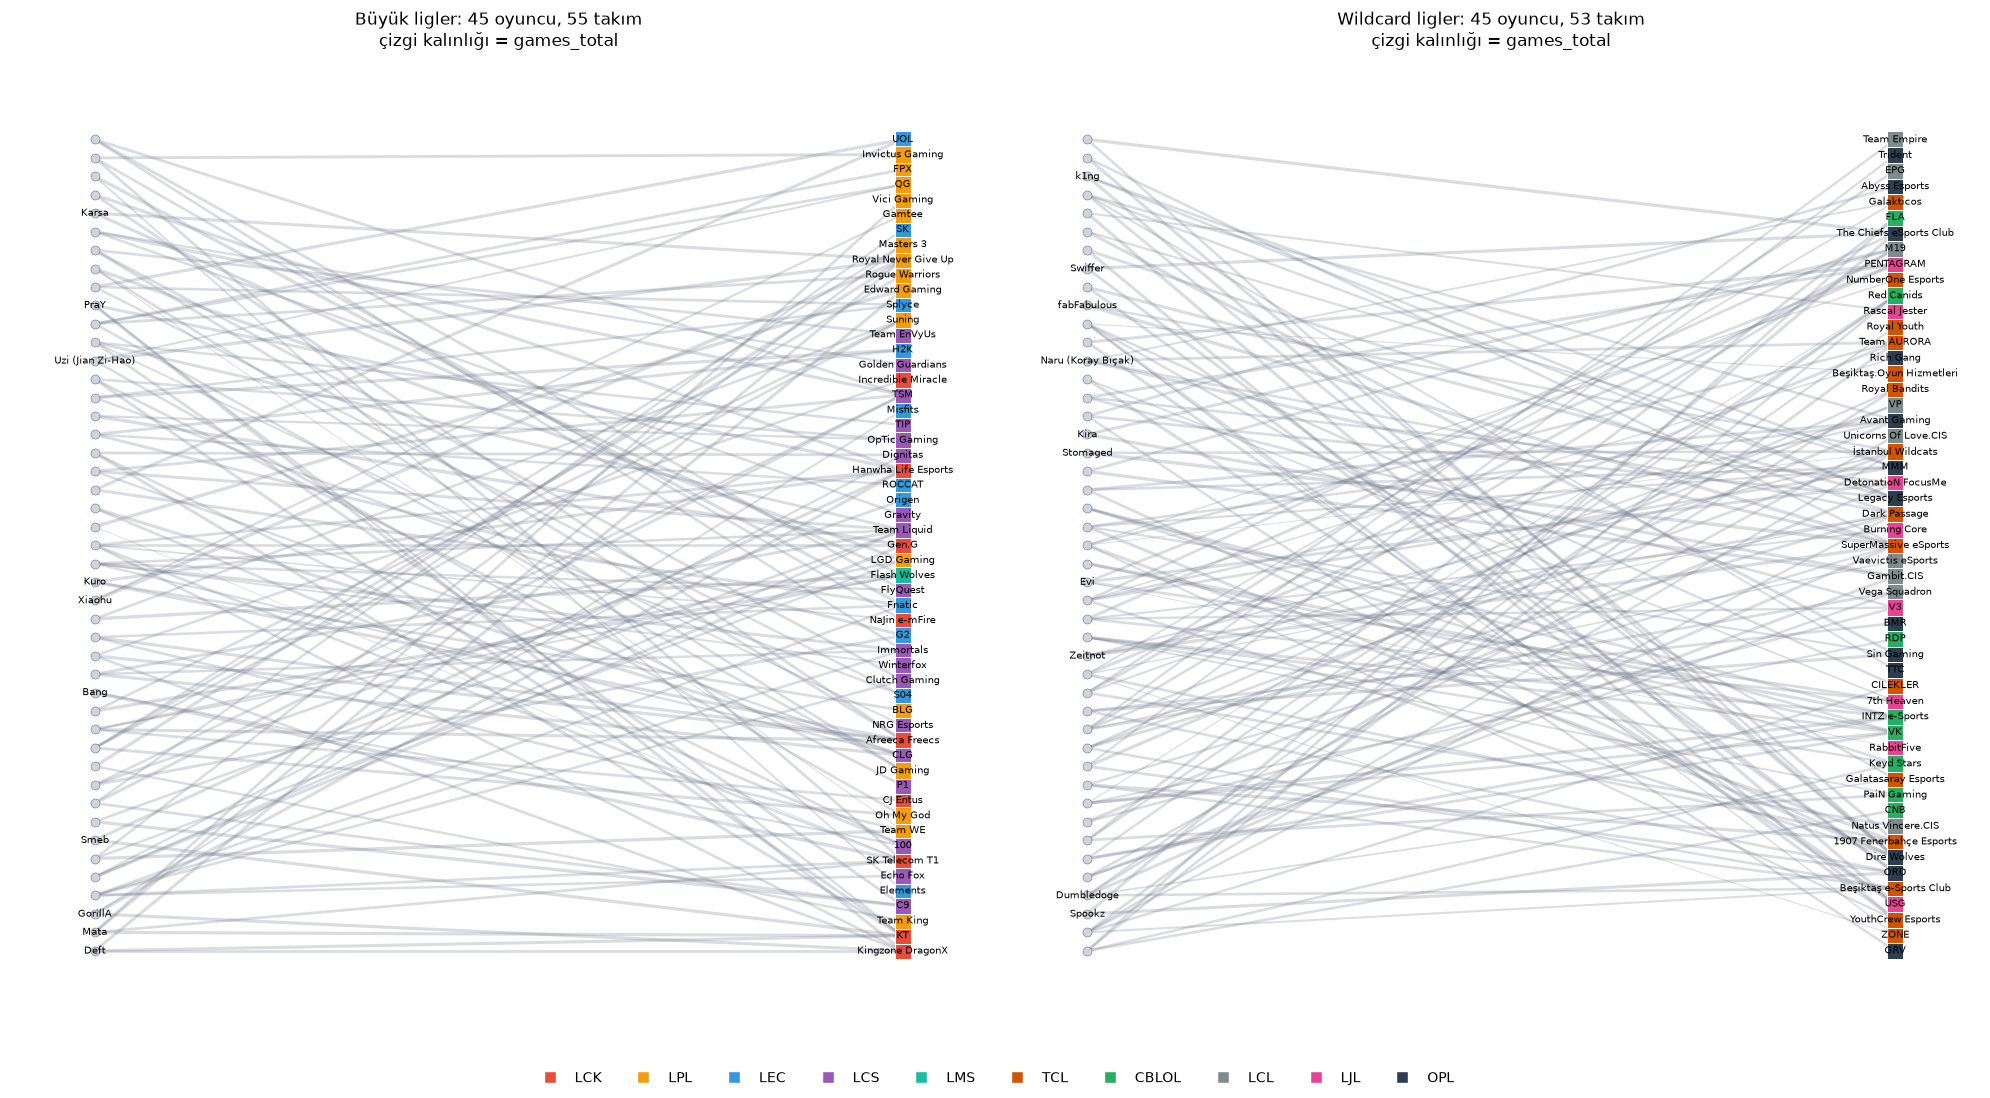

In [5]:
EDGE_WEIGHT = "games_total"
TOP_PLAYERS_TO_DRAW = 45
MIN_PLAYER_DEGREE = 2
PLAYER_LABEL_COUNT = 10

LEAGUE_COLORS = {
    "LCK": "#E74C3C", "LPL": "#F39C12", "LEC": "#3498DB",
    "LCS": "#9B59B6", "LMS": "#1ABC9C",
    "TCL": "#D35400", "CBLOL": "#27AE60", "LCL": "#7F8C8D",
    "LJL": "#E84393", "OPL": "#2C3E50",
}

def visual_subgraph(graph):
    players = [
        n for n, a in graph.nodes(data=True)
        if a["node_type"] == "player" and graph.degree(n) >= MIN_PLAYER_DEGREE
    ]
    players = sorted(
        players,
        key=lambda n: graph.degree(n, weight=EDGE_WEIGHT),
        reverse=True,
    )[:TOP_PLAYERS_TO_DRAW]
    teams = set(chain.from_iterable(set(graph.neighbors(p)) for p in players))
    return graph.subgraph(set(players) | teams).copy(), players

def draw_bipartite(graph, title, ax):
    shown, players = visual_subgraph(graph)
    if not shown:
        ax.set_title(f"{title} — gösterilecek düğüm yok")
        ax.axis("off")
        return

    pos = nx.bipartite_layout(
        shown, players, align="vertical", scale=1.0, aspect_ratio=1.8
    )
    team_nodes = [n for n in shown if shown.nodes[n]["node_type"] == "team"]
    edge_values = np.array(
        [shown[u][v][EDGE_WEIGHT] for u, v in shown.edges()], dtype=float
    )
    edge_widths = 0.35 + 2.2 * np.log1p(edge_values) / np.log1p(edge_values.max())

    nx.draw_networkx_edges(
        shown, pos, ax=ax, width=edge_widths, alpha=0.24, edge_color="#667085"
    )
    nx.draw_networkx_nodes(
        shown, pos, nodelist=players, ax=ax,
        node_size=42, node_color="#D0D5DD", edgecolors="#667085", linewidths=0.4
    )
    nx.draw_networkx_nodes(
        shown, pos, nodelist=team_nodes, ax=ax,
        node_size=135,
        node_color=[
            LEAGUE_COLORS.get(shown.nodes[n]["league"], "#111827")
            for n in team_nodes
        ],
        node_shape="s", edgecolors="white", linewidths=0.7,
    )

    labelled_players = sorted(
        players,
        key=lambda n: shown.degree(n, weight=EDGE_WEIGHT),
        reverse=True,
    )[:PLAYER_LABEL_COUNT]
    labels = {
        n: shown.nodes[n]["label"]
        for n in team_nodes + labelled_players
    }
    nx.draw_networkx_labels(shown, pos, labels=labels, font_size=7, ax=ax)
    ax.set_title(
        f"{title}: {len(players)} oyuncu, {len(team_nodes)} takım\n"
        "çizgi kalınlığı = games_total"
    )
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(20, 11))
draw_bipartite(graphs["major"], "Büyük ligler", axes[0])
draw_bipartite(graphs["wildcard"], "Wildcard ligler", axes[1])

legend = [
    Line2D([0], [0], marker="s", color="w", label=league,
           markerfacecolor=color, markersize=9)
    for league, color in LEAGUE_COLORS.items()
]
fig.legend(handles=legend, loc="lower center", ncol=10, frameon=False)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## 6. Build team and team-year tables

- Estimate team games from player appearances divided by five.
- Normalize success within each league.
- Measure roster continuity with Jaccard overlap between consecutive recorded rosters.

In [ ]:
team_base = (
    raw.groupby("team_node", as_index=False, sort=True)
       .agg(
           team_name=("team_name", "last"),
           team_name_at_time=("team_name_at_time", pipe_union),
           team_name_history=("team_name_history", pipe_union),
           league=("leagues", pipe_union),
           group=("group", pipe_union),
           games_domestic_player_sum=("games_domestic", "sum"),
           wins_domestic_player_sum=("wins_domestic", "sum"),
           minutes_domestic_player_sum=("minutes_domestic", "sum"),
           games_international_player_sum=("games_international", "sum"),
           wins_international_player_sum=("wins_international", "sum"),
           games_total_player_sum=("games_total", "sum"),
           active_year_list=("active_years", year_union),
       )
)

team_table = team_base.copy()
team_table["active_years"] = team_table["active_year_list"].map(
    lambda years: "|".join(map(str, years))
)
team_table["active_year_count"] = team_table["active_year_list"].map(len)
team_table["domestic_games"] = team_table["games_domestic_player_sum"] / 5
team_table["domestic_wins"] = team_table["wins_domestic_player_sum"] / 5
team_table["domestic_games_per_active_year"] = (
    team_table["domestic_games"] / team_table["active_year_count"]
)
team_table["domestic_wins_per_active_year"] = (
    team_table["domestic_wins"] / team_table["active_year_count"]
)
team_table["domestic_win_rate"] = (
    team_table["domestic_wins"]
    .div(team_table["domestic_games"].replace(0, np.nan))
)
team_table["international_participation"] = (
    team_table["games_international_player_sum"] > 0
).astype(int)

team_table["success_percentile_in_league"] = (
    team_table.groupby("league")["domestic_wins_per_active_year"]
              .rank(method="average", pct=True)
)

membership_rows = []
for row in raw[["player_node", "team_node", "active_years"]].itertuples(index=False):
    for year in year_union([row.active_years]):
        membership_rows.append(
            {"team_node": row.team_node, "year": year, "player_node": row.player_node}
        )

memberships = pd.DataFrame(membership_rows)
roster_sets = (
    memberships.groupby(["team_node", "year"])["player_node"]
               .agg(lambda values: set(values))
               .reset_index(name="players")
)

continuity_rows = []
for team_node, history in roster_sets.groupby("team_node", sort=True):
    history = history.sort_values("year")
    previous_year = None
    previous_players = None
    for row in history.itertuples(index=False):
        current_players = row.players
        is_consecutive = (
            previous_year is not None and row.year == previous_year + 1
        )
        retained = (
            len(previous_players & current_players) if is_consecutive else np.nan
        )
        union_size = (
            len(previous_players | current_players) if is_consecutive else np.nan
        )
        continuity_rows.append(
            {
                "team_node": team_node,
                "year": row.year,
                "previous_year": previous_year if is_consecutive else np.nan,
                "recorded_roster_size": len(current_players),
                "retained_recorded_players": retained,
                "recorded_roster_continuity": (
                    retained / union_size if is_consecutive and union_size else np.nan
                ),
                "retained_share_of_previous_roster": (
                    retained / len(previous_players)
                    if is_consecutive and previous_players else np.nan
                ),
                "player_nodes": "|".join(sorted(current_players)),
            }
        )
        previous_year = row.year
        previous_players = current_players

team_year_table = pd.DataFrame(continuity_rows).merge(
    team_table[["team_node", "team_name", "league", "group"]],
    on="team_node",
    how="left",
)

retention_summary = (
    team_year_table.groupby("team_node", as_index=False)
                   .agg(
                       measured_transitions=(
                           "recorded_roster_continuity", "count"
                       ),
                       mean_recorded_roster_continuity=(
                           "recorded_roster_continuity", "mean"
                       ),
                       mean_retained_share_previous=(
                           "retained_share_of_previous_roster", "mean"
                       ),
                   )
)
team_table = team_table.merge(retention_summary, on="team_node", how="left")
team_table = team_table.drop(columns=["active_year_list"])

display(
    team_table.sort_values(
        ["league", "success_percentile_in_league"],
        ascending=[True, False],
    ).head(20)
)
display(team_year_table.head(20))

,team_node,team_name,team_name_at_time,team_name_history,league,group,games_domestic_player_sum,wins_domestic_player_sum,minutes_domestic_player_sum,games_international_player_sum,...,domestic_games,domestic_wins,domestic_games_per_active_year,domestic_wins_per_active_year,domestic_win_rate,international_participation,success_percentile_in_league,measured_transitions,mean_recorded_roster_continuity,mean_retained_share_previous
67,team::fla,FLA,FLA,FLA,CBLOL,wildcard,425,320.0,13953.500000,25.0,...,85.0,64.0,42.500000,32.000000,0.752941,1,1.000,1,0.375000,0.600000
105,team::intzesports,INTZ e-Sports,INTZ e-Sports,INTZ e-Sports,CBLOL,wildcard,1135,730.0,41303.666667,60.0,...,227.0,146.0,45.400000,29.200000,0.643172,1,0.950,4,0.374752,0.542460
116,team::keydstars,Keyd Stars,Keyd Stars,Keyd Stars,CBLOL,wildcard,595,360.0,22604.666667,0.0,...,119.0,72.0,39.666667,24.000000,0.605042,0,0.900,2,0.283217,0.370130
162,team::rdp,RDP,RDP,RDP,CBLOL,wildcard,235,105.0,8175.750000,0.0,...,47.0,21.0,47.000000,21.000000,0.446809,0,0.825,0,NaN,NaN
226,team::uppercutesports,Uppercut esports,Uppercut esports,Uppercut esports,CBLOL,wildcard,225,105.0,7295.083333,0.0,...,45.0,21.0,45.000000,21.000000,0.466667,0,0.825,0,NaN,NaN
234,team::vk,VK,VK,VK,CBLOL,wildcard,365,185.0,12467.333333,0.0,...,73.0,37.0,36.500000,18.500000,0.506849,0,0.750,1,0.444444,0.800000
155,team::paingaming,PaiN Gaming,PaiN Gaming,PaiN Gaming,CBLOL,wildcard,820,455.0,32256.083333,24.0,...,164.0,91.0,32.800000,18.200000,0.554878,1,0.700,4,0.321581,0.498810
31,team::cnb,CNB,CNB,CNB,CBLOL,wildcard,1015,450.0,38254.583333,0.0,...,203.0,90.0,40.600000,18.000000,0.443350,0,0.650,4,0.305114,0.440972
163,team::redcanids,Red Canids,INTZ Red | Red Canids,INTZ Red | Red Canids,CBLOL,wildcard,675,355.0,26476.750000,30.0,...,135.0,71.0,33.750000,17.750000,0.525926,1,0.600,3,0.245754,0.398810
114,team::kabumesports,KaBuM! Esports,KaBuM! Esports | KaBuM! Orange,KaBuM! Esports | KaBuM! Orange,CBLOL,wildcard,870,420.0,31154.666667,55.0,...,174.0,84.0,34.800000,16.800000,0.482759,1,0.550,4,0.328571,0.526515


,team_node,year,previous_year,recorded_roster_size,retained_recorded_players,recorded_roster_continuity,retained_share_of_previous_roster,player_nodes,team_name,league,group
0,team::100,2018,NaN,7,NaN,NaN,NaN,player::anda|player::aphromoo|player::cody-sun...,100,LCS,major
1,team::100,2019,2018.0,11,4.0,0.285714,0.571429,player::amazing-maurice-stuckenschneider|playe...,100,LCS,major
2,team::1907fenerbahceesports,2017,NaN,8,NaN,NaN,NaN,player::elysion|player::frozen-kim-tae-il|play...,1907 Fenerbahçe Esports,TCL,wildcard
3,team::1907fenerbahceesports,2018,2017.0,8,4.0,0.333333,0.500000,player::chaser|player::frozen-kim-tae-il|playe...,1907 Fenerbahçe Esports,TCL,wildcard
4,team::1907fenerbahceesports,2019,2018.0,12,1.0,0.052632,0.125000,player::agurin|player::blue-ersin-goren|player...,1907 Fenerbahçe Esports,TCL,wildcard
5,team::4notoce,2015,NaN,6,NaN,NaN,NaN,player::carlos-is-god|player::cnj|player::kulo...,4not.oce,OPL,wildcard
6,team::7thheaven,2015,NaN,10,NaN,NaN,NaN,player::alvingo|player::clockday|player::enty|...,7th Heaven,LJL,wildcard
7,team::7thheaven,2016,2015.0,10,2.0,0.111111,0.200000,player::awaker-kentaro-hanaoka|player::beni-ry...,7th Heaven,LJL,wildcard
8,team::7thheaven,2017,2016.0,9,5.0,0.357143,0.500000,player::broooock|player::estelim|player::naemi...,7th Heaven,LJL,wildcard
9,team::7thheaven,2018,2017.0,7,5.0,0.454545,0.555556,player::haretti|player::hw4ng|player::raizin|p...,7th Heaven,LJL,wildcard


## 7. Compare success and roster continuity

Compare league-normalized success with roster continuity. The results are correlational, not causal.

,league,teams,spearman_success_vs_continuity
0,CBLOL,12,0.636
1,LCK,13,-0.421
2,LCL,9,0.311
3,LCS,15,0.267
4,LEC,12,0.718
5,LJL,9,0.050
6,LMS,10,0.515
7,LPL,19,0.269
8,OPL,10,0.321
9,TCL,12,0.399


,international_participation,teams,mean_recorded_roster_continuity,median_recorded_roster_continuity
0,0,71,0.217,0.193
1,1,50,0.320,0.317


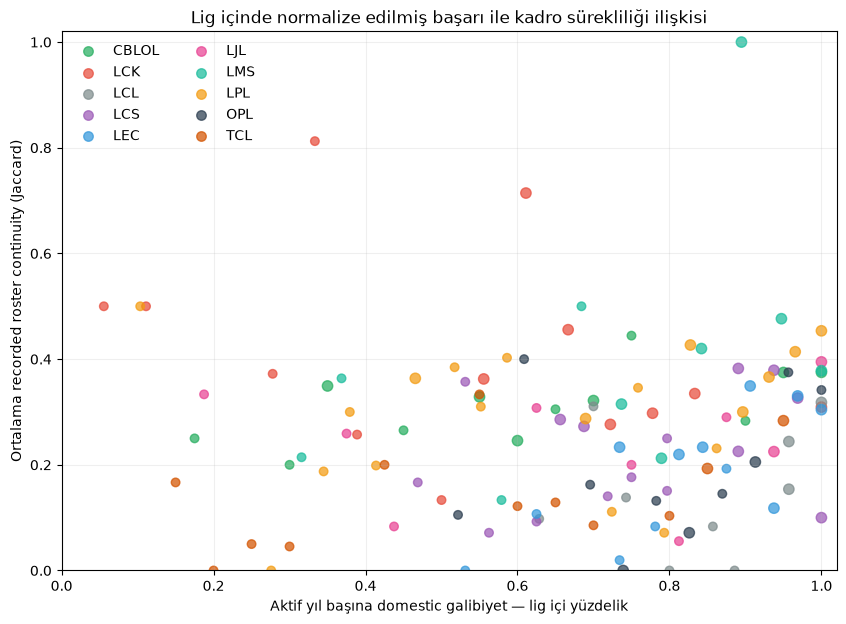

In [7]:
analysis_table = team_table[
    team_table["measured_transitions"].fillna(0).gt(0)
    & team_table["success_percentile_in_league"].notna()
].copy()

league_rows = []
for league, frame in analysis_table.groupby("league"):
    x = frame["success_percentile_in_league"]
    y = frame["mean_recorded_roster_continuity"]
    league_rows.append(
        {
            "league": league,
            "teams": len(frame),
            "spearman_success_vs_continuity": (
                x.rank().corr(y.rank()) if len(frame) >= 3 else np.nan
            ),
        }
    )
league_relationship = pd.DataFrame(league_rows)

international_comparison = (
    analysis_table.groupby("international_participation")
                  .agg(
                      teams=("team_node", "count"),
                      mean_recorded_roster_continuity=(
                          "mean_recorded_roster_continuity", "mean"
                      ),
                      median_recorded_roster_continuity=(
                          "mean_recorded_roster_continuity", "median"
                      ),
                  )
                  .reset_index()
)

display(league_relationship.round(3))
display(international_comparison.round(3))

fig, ax = plt.subplots(figsize=(10, 7))
for league, frame in analysis_table.groupby("league"):
    ax.scatter(
        frame["success_percentile_in_league"],
        frame["mean_recorded_roster_continuity"],
        s=38 + 18 * frame["international_participation"],
        alpha=0.72,
        color=LEAGUE_COLORS.get(league, "#111827"),
        label=league,
    )
ax.set(
    xlabel="Aktif yıl başına domestic galibiyet — lig içi yüzdelik",
    ylabel="Ortalama recorded roster continuity (Jaccard)",
    title="Lig içinde normalize edilmiş başarı ile kadro sürekliliği ilişkisi",
    xlim=(0, 1.02),
    ylim=(0, 1.02),
)
ax.grid(alpha=0.2)
ax.legend(ncol=2, frameon=False)
plt.show()

## 8. Optional export

Save tables and the graph only when `EXPORT_FILES` is enabled.

In [8]:
EXPORT_FILES = False

if EXPORT_FILES:
    export_dir = ROOT / "outputs" / "tek_notebook"
    export_dir.mkdir(parents=True, exist_ok=True)
    edge_table.to_csv(export_dir / "player_team_edges.csv", index=False)
    graph_metrics.to_csv(export_dir / "graph_summary.csv", index=False)
    team_table.to_csv(export_dir / "team_summary.csv", index=False)
    team_year_table.to_csv(export_dir / "team_year_roster_continuity.csv", index=False)
    league_relationship.to_csv(
        export_dir / "league_success_continuity_relationship.csv", index=False
    )
    nx.write_graphml(G, export_dir / "player_team_lineage.graphml")
    print("Yazıldı:", export_dir)
else:
    print("Dosya yazılmadı. Dışa aktarmak için EXPORT_FILES = True yap.")

Dosya yazılmadı. Dışa aktarmak için EXPORT_FILES = True yap.


## Interpretation limits

- An edge means at least one recorded match for that player–team lineage.
- International games do not distinguish Worlds from MSI.
- Recorded rosters may include substitutes.
- All reported relationships are observational.